# Customer Fraud Detection – Binary Classification

## Project Overview

This project focuses on detecting fraudulent customer transactions using Machine Learning classification techniques.

The target variable is **`is_fraudulent`**:

* `0` = Not Fraudulent
* `1` = Fraudulent

### Objectives

In this project, we will:

1. Load and understand the dataset.
2. Perform Exploratory Data Analysis (EDA).
3. Handle missing values and duplicate records.
4. Perform data preprocessing.
5. Encode categorical variables.
6. Apply feature scaling where required.
7. Handle class imbalance using SMOTE.
8. Train multiple classification models:

   * Decision Tree
   * Random Forest
   * XGBoost
9. Evaluate and compare model performance.
10. Identify the best-performing model.
11. Present final conclusions and recommendations.


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("customer_analytics_dataset.csv")

# Display first 5 rows
df.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


## 1. Dataset Overview

Before building the machine learning models, we first examine the structure, size, data types, and missing values in the dataset.

This step helps us understand the quality of the data and identify preprocessing requirements.


In [2]:
# Check dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types and non-null values
print("\nDataset Information:")
df.info()

Number of rows: 5000
Number of columns: 13

Column Names:
['customer_id', 'age', 'gender', 'country', 'avg_order_value', 'total_orders', 'last_purchase', 'is_fraudulent', 'preferred_category', 'email_open_rate', 'customer_since', 'loyalty_score', 'churn_risk']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   object 
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   object 
 3   country             5000 non-null   object 
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   object 
 9   email_open_rate     4750 non-null   float64
 10  customer_since   

In [3]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.163200,17.880797,18.00,33.000,48.00,64.0000,79.00
avg_order_value,4750.0,108.442857,69.265559,10.66,57.805,93.19,142.1975,555.46
total_orders,5000.0,10.027000,3.163838,0.00,8.000,10.00,12.0000,23.00
last_purchase,5000.0,180.073200,104.926518,0.00,89.000,178.00,270.0000,364.00
is_fraudulent,5000.0,0.025800,0.158554,0.00,0.000,0.00,0.0000,1.00
email_open_rate,4750.0,50.714842,29.098706,0.00,25.225,50.95,76.8000,100.00
loyalty_score,5000.0,50.039400,28.832151,1.00,25.000,50.00,75.0000,99.00
churn_risk,5000.0,0.284484,0.159690,0.00,0.160,0.26,0.3900,0.90


# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the patterns, distributions, relationships, and quality of the dataset before applying machine learning algorithms.

We will analyze:

* Missing values
* Duplicate records
* Target-class distribution
* Numerical feature distributions
* Categorical feature distributions
* Relationships between features and fraud


In [4]:
# Check missing values

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
avg_order_value,250,5.0
email_open_rate,250,5.0


In [5]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


is_fraudulent
0    4871
1     129
Name: count, dtype: int64

Percentage Distribution:
is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64


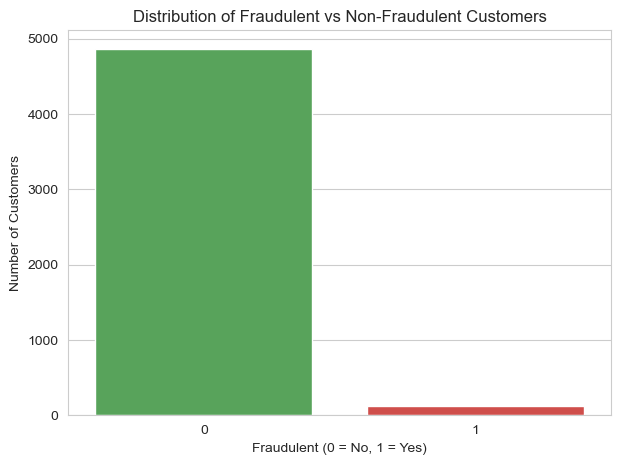

In [6]:
# Count fraud and non-fraud cases

fraud_counts = df["is_fraudulent"].value_counts()

print(fraud_counts)

# Percentage distribution
fraud_percentage = df["is_fraudulent"].value_counts(normalize=True) * 100

print("\nPercentage Distribution:")
print(fraud_percentage)

# Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_fraudulent",
    hue="is_fraudulent",
    palette=["#4CAF50", "#E53935"],
    legend=False
)

plt.title("Distribution of Fraudulent vs Non-Fraudulent Customers")
plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

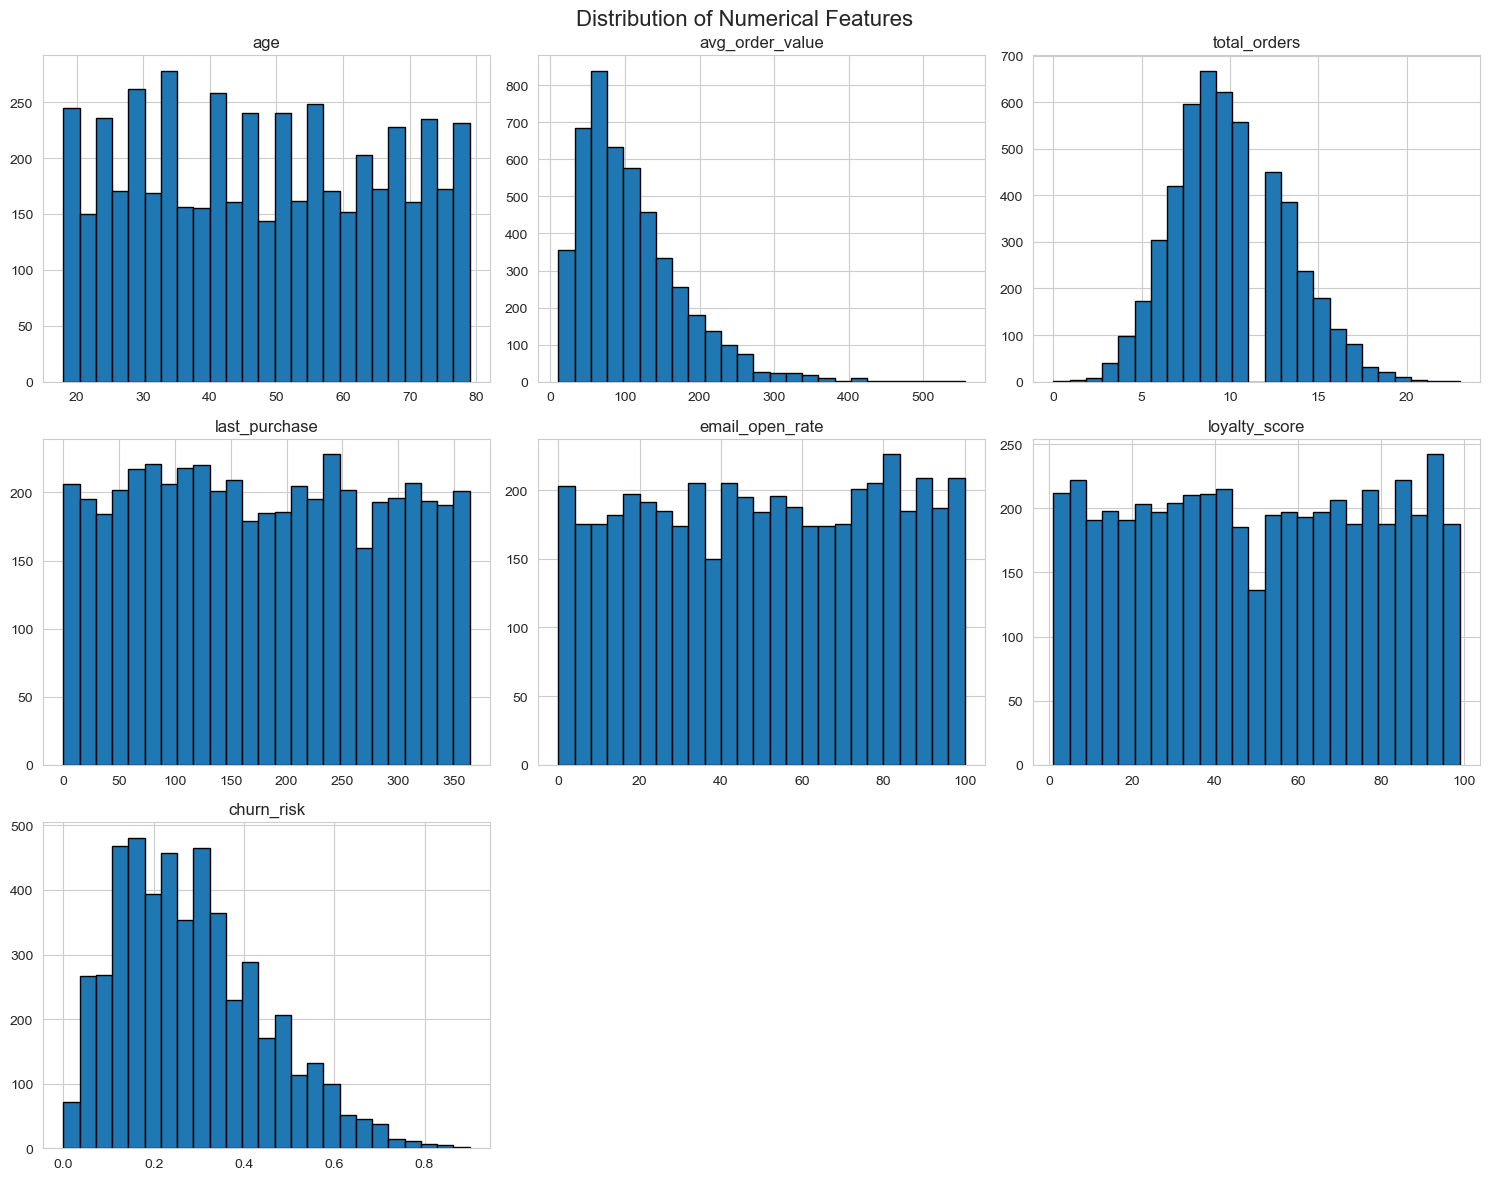

In [7]:
# Select numerical columns
numeric_columns = [
    "age",
    "avg_order_value",
    "total_orders",
    "last_purchase",
    "email_open_rate",
    "loyalty_score",
    "churn_risk"
]

# Plot distributions
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=25,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# 3. Categorical Feature Analysis

The dataset contains several categorical variables such as gender, country, and preferred category.

We analyze their frequency distributions to understand the composition of the customer data and identify possible patterns that may be useful for fraud detection.


In [8]:
# Identify categorical columns

categorical_columns = [
    "gender",
    "country",
    "preferred_category"
]

for column in categorical_columns:
    print(f"\n--- {column.upper()} ---")
    print(df[column].value_counts())


--- GENDER ---
gender
Male      2278
Female    2242
Other      480
Name: count, dtype: int64

--- COUNTRY ---
country
Australia    518
USA          517
India        511
Germany      509
Brazil       504
France       500
China        497
Canada       490
UK           485
Japan        469
Name: count, dtype: int64

--- PREFERRED_CATEGORY ---
preferred_category
Beauty         1035
Electronics    1021
Home           1004
Fashion         975
Sports          965
Name: count, dtype: int64


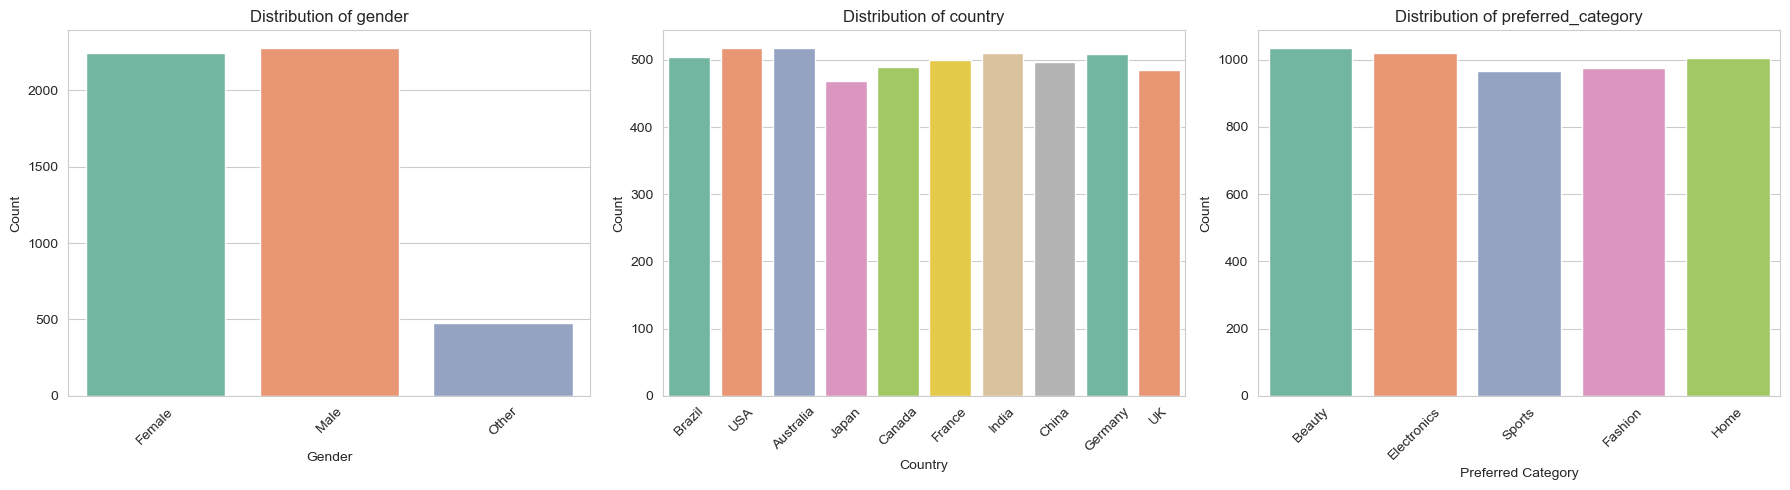

In [9]:
# Visualize categorical features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, categorical_columns):
    sns.countplot(
        data=df,
        x=column,
        hue=column,
        palette="Set2",
        legend=False,
        ax=ax
    )
    
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Count")
    
    # Rotate labels where necessary
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Calculate fraud rate for each categorical feature

for column in categorical_columns:
    fraud_rate = (
        df.groupby(column)["is_fraudulent"]
        .agg(["count", "sum", "mean"])
        .sort_values("mean", ascending=False)
    )
    
    fraud_rate["fraud_rate_%"] = fraud_rate["mean"] * 100
    
    print(f"\nFraud Rate by {column}:")
    display(fraud_rate)


Fraud Rate by gender:


,count,sum,mean,fraud_rate_%
gender,,,,
Female,2242,62,0.027654,2.765388
Other,480,12,0.025000,2.500000
Male,2278,55,0.024144,2.414399



Fraud Rate by country:


,count,sum,mean,fraud_rate_%
country,,,,
Japan,469,18,0.038380,3.837953
Brazil,504,19,0.037698,3.769841
USA,517,16,0.030948,3.094778
UK,485,14,0.028866,2.886598
Germany,509,13,0.025540,2.554028
India,511,11,0.021526,2.152642
Australia,518,11,0.021236,2.123552
Canada,490,10,0.020408,2.040816
China,497,10,0.020121,2.012072



Fraud Rate by preferred_category:


,count,sum,mean,fraud_rate_%
preferred_category,,,,
Electronics,1021,33,0.032321,3.232125
Home,1004,32,0.031873,3.187251
Fashion,975,31,0.031795,3.179487
Sports,965,17,0.017617,1.761658
Beauty,1035,16,0.015459,1.545894


## 4. Fraud Pattern Analysis

Next, we examine how numerical variables are related to fraudulent behavior.

Comparing feature distributions between fraudulent and non-fraudulent customers can help identify potentially useful predictors for the classification models.


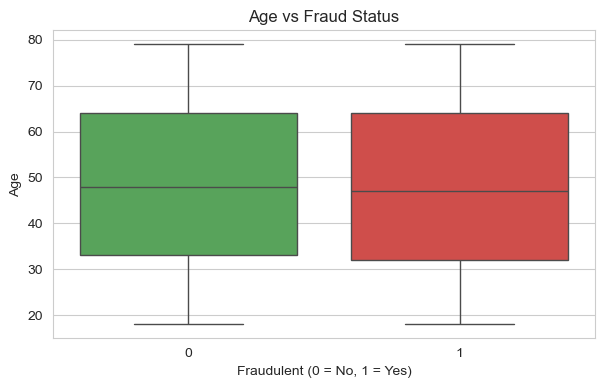

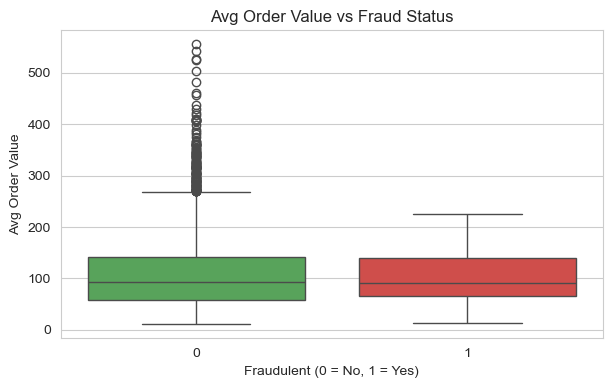

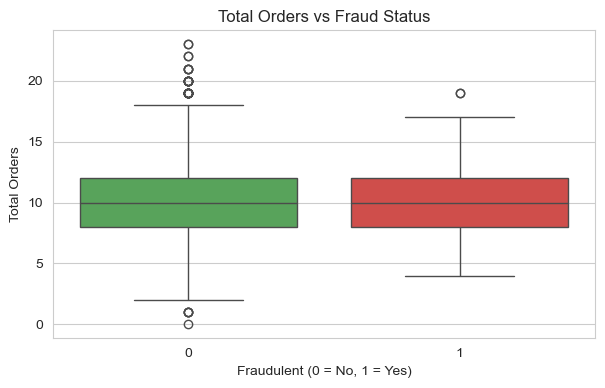

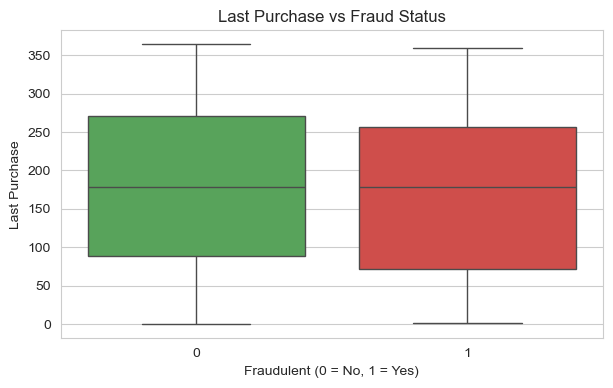

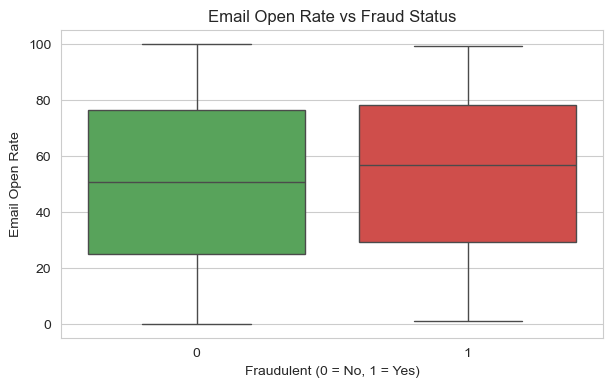

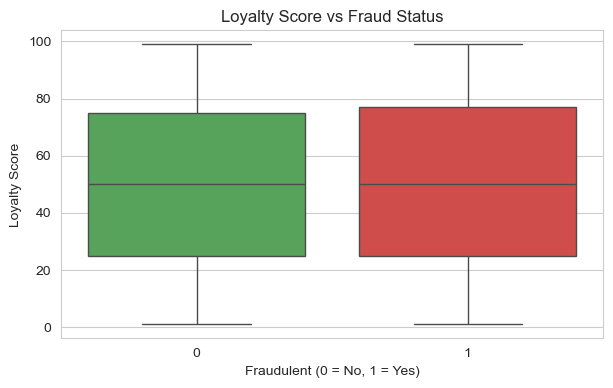

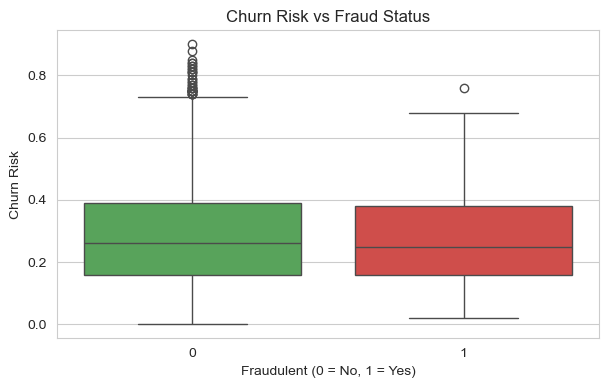

In [11]:
# Compare numerical features by fraud status

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        data=df,
        x="is_fraudulent",
        y=column,
        hue="is_fraudulent",
        palette=["#4CAF50", "#E53935"],
        legend=False
    )
    
    plt.title(f"{column.replace('_', ' ').title()} vs Fraud Status")
    plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
    plt.ylabel(column.replace("_", " ").title())
    
    plt.show()

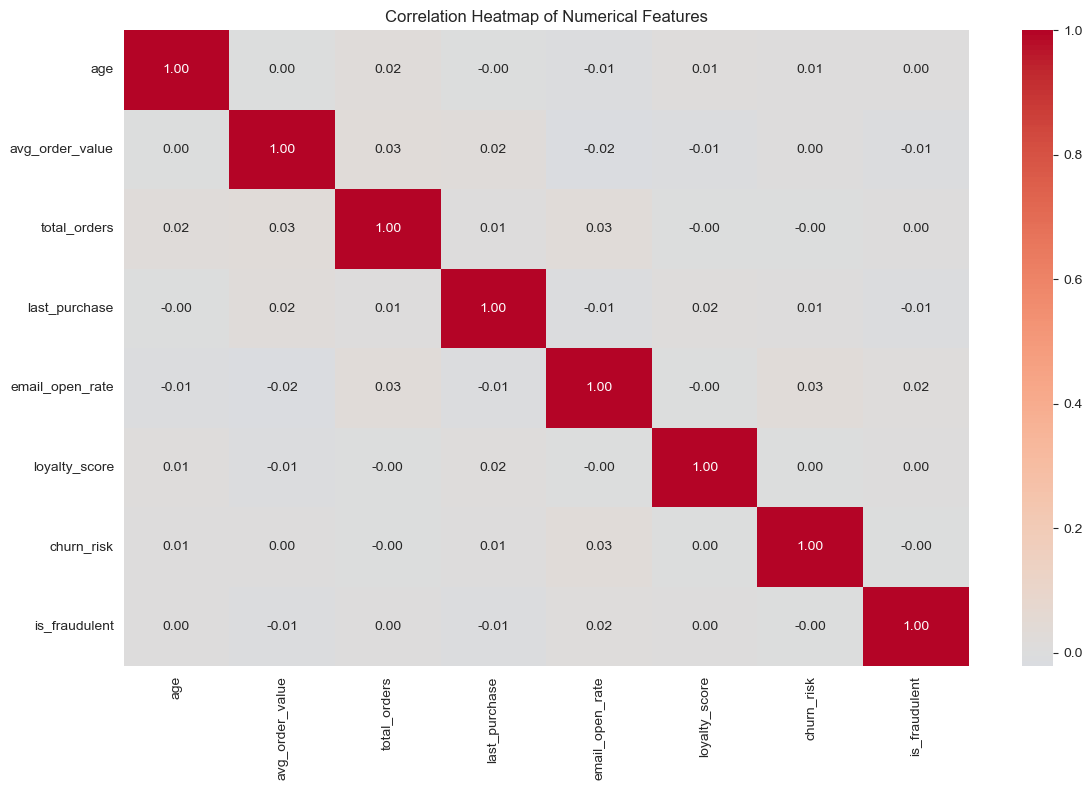

In [12]:
# Correlation analysis

plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_columns + ["is_fraudulent"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [13]:
# Compare average values of numerical features for fraud and non-fraud customers

fraud_comparison = df.groupby("is_fraudulent")[numeric_columns].mean().T

fraud_comparison.columns = ["Not Fraudulent", "Fraudulent"]

fraud_comparison

,Not Fraudulent,Fraudulent
age,48.153767,48.519380
avg_order_value,108.567051,103.809597
total_orders,10.025867,10.069767
last_purchase,180.205091,175.093023
email_open_rate,50.635133,53.816807
loyalty_score,50.021556,50.713178
churn_risk,0.284576,0.281008


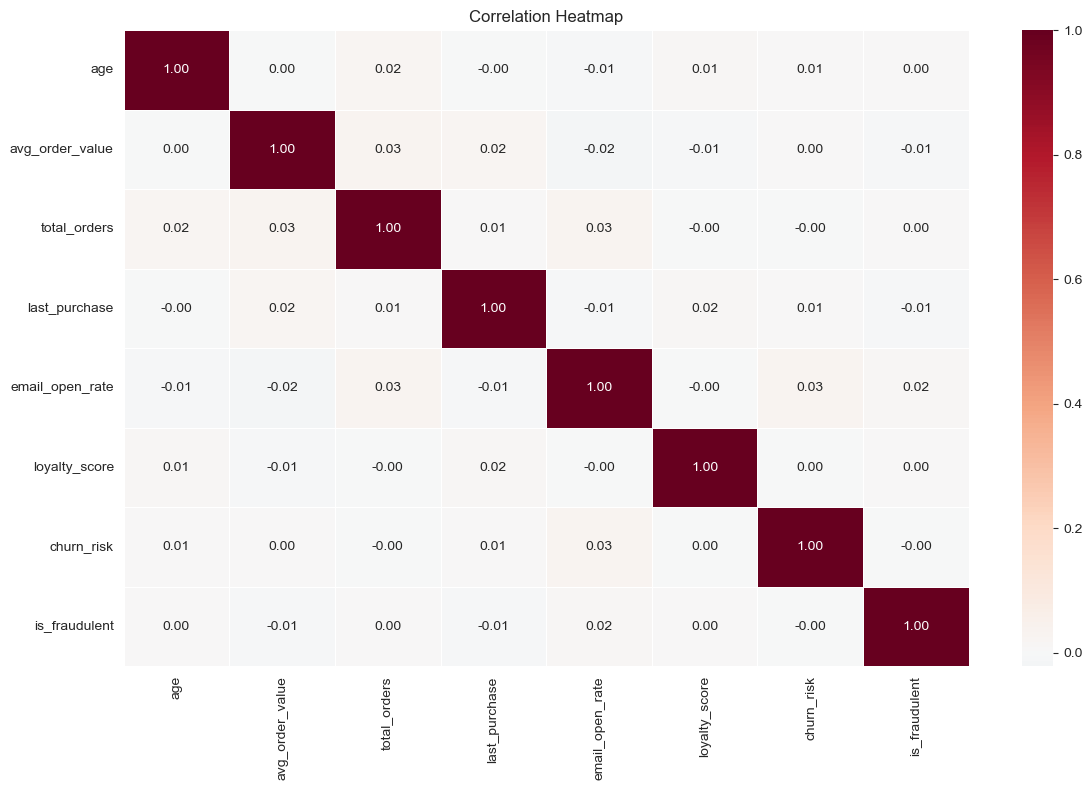

In [14]:
# Correlation heatmap

correlation_columns = numeric_columns + ["is_fraudulent"]

plt.figure(figsize=(12, 8))

corr = df[correlation_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. EDA Findings

The exploratory analysis shows that the dataset is highly imbalanced, with fraudulent customers representing only a small proportion of the total observations.

The categorical analysis also shows differences in fraud rates across countries, genders, and preferred product categories. For example, Japan and Brazil show relatively higher fraud rates than several other countries, while Electronics, Home, and Fashion have higher fraud rates among the preferred categories.

These observations indicate that categorical and numerical customer characteristics may contain useful information for fraud classification.

Because the target class is highly imbalanced, class-balancing techniques such as **SMOTE** will be considered during model preparation.


## 6. Data Preprocessing

Data preprocessing is an important step before training machine learning models.

In this stage, we will:

* Check and remove duplicate records.
* Handle missing numerical values.
* Convert the `customer_since` date into useful numerical features.
* Remove the original date column after feature extraction.
* Remove `customer_id` because it is an identifier and does not provide meaningful predictive information.
* Separate features (`X`) and target (`y`).


In [15]:
# Create a copy for preprocessing

data = df.copy()

# Check duplicate records
print("Duplicate rows before removal:", data.duplicated().sum())

# Remove duplicates
data = data.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", data.shape)

Duplicate rows before removal: 0
Dataset shape after removing duplicates: (5000, 13)


In [16]:
# Check missing values before treatment

print("Missing values before treatment:")
print(data.isnull().sum())

# Fill missing numerical values with median
data["avg_order_value"] = data["avg_order_value"].fillna(
    data["avg_order_value"].median()
)

data["email_open_rate"] = data["email_open_rate"].fillna(
    data["email_open_rate"].median()
)

print("\nMissing values after treatment:")
print(data.isnull().sum())

Missing values before treatment:
customer_id             0
age                     0
gender                  0
country                 0
avg_order_value       250
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate       250
customer_since          0
loyalty_score           0
churn_risk              0
dtype: int64

Missing values after treatment:
customer_id           0
age                   0
gender                0
country               0
avg_order_value       0
total_orders          0
last_purchase         0
is_fraudulent         0
preferred_category    0
email_open_rate       0
customer_since        0
loyalty_score         0
churn_risk            0
dtype: int64


In [17]:
# Convert customer_since to datetime
data["customer_since"] = pd.to_datetime(data["customer_since"])

# Extract useful date-based features
data["customer_since_year"] = data["customer_since"].dt.year
data["customer_since_month"] = data["customer_since"].dt.month
data["customer_since_days"] = (
    pd.Timestamp("2026-08-14") - data["customer_since"]
).dt.days

# Remove original date column
data.drop("customer_since", axis=1, inplace=True)

# Remove customer ID
data.drop("customer_id", axis=1, inplace=True)

# Check updated columns
data.head()

,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_since_year,customer_since_month,customer_since_days
0,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,2024,6,800
1,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,2024,2,907
2,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,2024,4,850
3,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,2020,7,2228
4,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,2025,4,492


## 7. Feature and Target Separation

The target variable for this project is `is_fraudulent`.

* `X` contains the input features.
* `y` contains the target variable.

The target will not be included among the input features because the model must learn to predict it.


In [18]:
# Separate features and target

X = data.drop("is_fraudulent", axis=1)
y = data["is_fraudulent"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (5000, 13)
Target shape: (5000,)

Target distribution:
is_fraudulent
0    4871
1     129
Name: count, dtype: int64


## 8. Categorical Encoding

Machine learning algorithms require numerical input, so categorical variables must be converted into numerical form.

We will use **One-Hot Encoding** for:

* `gender`
* `country`
* `preferred_category`

One-hot encoding creates separate binary columns for each category.

We will then split the data into training and testing sets using **stratification** so that the minority fraud class remains represented proportionally in both sets.


In [19]:
from sklearn.model_selection import train_test_split

# One-hot encode categorical features
X_encoded = pd.get_dummies(
    X,
    columns=["gender", "country", "preferred_category"],
    drop_first=True
)

# Convert boolean columns to integers
X_encoded = X_encoded.astype(int)

# Display encoded dataset
print("Encoded feature shape:", X_encoded.shape)

X_encoded.head()

Encoded feature shape: (5000, 25)


,age,avg_order_value,total_orders,last_purchase,email_open_rate,loyalty_score,churn_risk,customer_since_year,customer_since_month,customer_since_days,gender_Male,gender_Other,country_Brazil,country_Canada,country_China,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,preferred_category_Electronics,preferred_category_Fashion,preferred_category_Home,preferred_category_Sports
0,30,101,8,176,25,50,0,2024,6,800,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,53,90,10,88,12,37,0,2024,2,907,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
2,73,83,6,203,50,65,0,2024,4,850,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,30,109,9,346,42,93,0,2020,7,2228,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0
4,29,269,16,342,5,79,0,2025,4,492,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0


In [20]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (4000, 25)
Testing set: (1000, 25)

Training target distribution:
is_fraudulent
0    3897
1     103
Name: count, dtype: int64

Testing target distribution:
is_fraudulent
0    974
1     26
Name: count, dtype: int64


## 9. Feature Scaling

Feature scaling brings numerical features to a similar scale.

Although tree-based algorithms such as Decision Tree and Random Forest generally do not require scaling, scaling is useful for maintaining a consistent preprocessing pipeline and can be important for other machine learning algorithms.

The scaler will be fitted **only on the training data** to prevent data leakage.


In [21]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (4000, 25)
Scaled testing data shape: (1000, 25)


## 10. Handling Class Imbalance Using SMOTE

The target variable is highly imbalanced, with only 2.58% of observations belonging to the fraudulent class.

To address this imbalance, we use **Synthetic Minority Over-sampling Technique (SMOTE)**.

SMOTE generates synthetic samples for the minority class instead of simply duplicating existing observations.

SMOTE is applied only to the training dataset so that the test dataset remains representative of unseen real-world data.


In [22]:
from imblearn.over_sampling import SMOTE

# Check class distribution before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Check class distribution after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining data shape after SMOTE:", X_train_smote.shape)

Before SMOTE:
is_fraudulent
0    3897
1     103
Name: count, dtype: int64

After SMOTE:
is_fraudulent
0    3897
1    3897
Name: count, dtype: int64

Training data shape after SMOTE: (7794, 25)


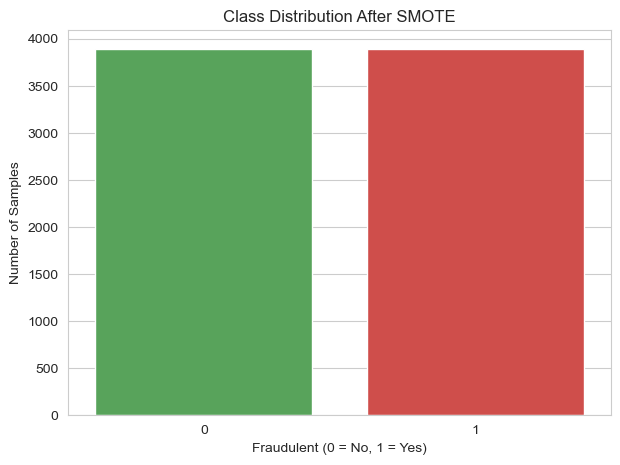

In [23]:
# Visualize class distribution after SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette=["#4CAF50", "#E53935"],
    legend=False
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Number of Samples")

plt.show()


## 11. Machine Learning Model Training

After preprocessing and class balancing, we are ready to train the classification models.

The following algorithms will be evaluated:

1. **Decision Tree Classifier**
2. **Random Forest Classifier**
3. **XGBoost Classifier**

These models will be trained using the balanced training dataset created with SMOTE.


## 12. Decision Tree Classifier

A Decision Tree is a supervised learning algorithm that makes predictions by splitting the data into branches based on feature values.

It is easy to interpret and can be used for both classification and regression problems.


In [24]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5
)

# Train model
dt_model.fit(X_train_smote, y_train_smote)

# Predictions
dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 13. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It generally provides better generalization than a single decision tree and helps reduce overfitting by combining predictions from multiple trees.


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 14. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm based on gradient boosting.

It builds models sequentially, where each new model attempts to correct the errors made by previous models. XGBoost is widely used for structured and tabular datasets.


In [26]:
# Install XGBoost
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.


In [27]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
xgb_pred = xgb_model.predict(X_test_scaled)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [28]:
print("All three models have been trained successfully.")

All three models have been trained successfully.


## 15. Model Evaluation

To compare the performance of the three classification models, we will use multiple evaluation metrics.

Because the dataset is highly imbalanced, **Accuracy alone is not sufficient**. We will evaluate:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

These metrics provide a more complete understanding of fraud-detection performance.


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Function to evaluate a model
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")
    
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1-Score :", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))

In [30]:
# Get probability predictions

dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate all models

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)


Decision Tree
Accuracy : 0.641
Precision: 0.0256
Recall   : 0.3462
F1-Score : 0.0477
ROC-AUC  : 0.4933

Random Forest
Accuracy : 0.898
Precision: 0.025
Recall   : 0.0769
F1-Score : 0.0377
ROC-AUC  : 0.5468

XGBoost
Accuracy : 0.974
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0
ROC-AUC  : 0.5449


In [31]:
print("Test: Cell is running")

Test: Cell is running


In [32]:
# Classification reports for all models

print("DECISION TREE")
print(classification_report(y_test, dt_pred, target_names=["Not Fraudulent", "Fraudulent"]))

print("\nRANDOM FOREST")
print(classification_report(y_test, rf_pred, target_names=["Not Fraudulent", "Fraudulent"]))

print("\nXGBOOST")
print(classification_report(y_test, xgb_pred, target_names=["Not Fraudulent", "Fraudulent"]))

DECISION TREE
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.65      0.78       974
    Fraudulent       0.03      0.35      0.05        26

      accuracy                           0.64      1000
     macro avg       0.50      0.50      0.41      1000
  weighted avg       0.95      0.64      0.76      1000


RANDOM FOREST
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.92      0.95       974
    Fraudulent       0.03      0.08      0.04        26

      accuracy                           0.90      1000
     macro avg       0.50      0.50      0.49      1000
  weighted avg       0.95      0.90      0.92      1000


XGBOOST
                precision    recall  f1-score   support

Not Fraudulent       0.97      1.00      0.99       974
    Fraudulent       0.00      0.00      0.00        26

      accuracy                           0.97      1000
     macro avg       0.49      0.50      0.49      1000
  

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


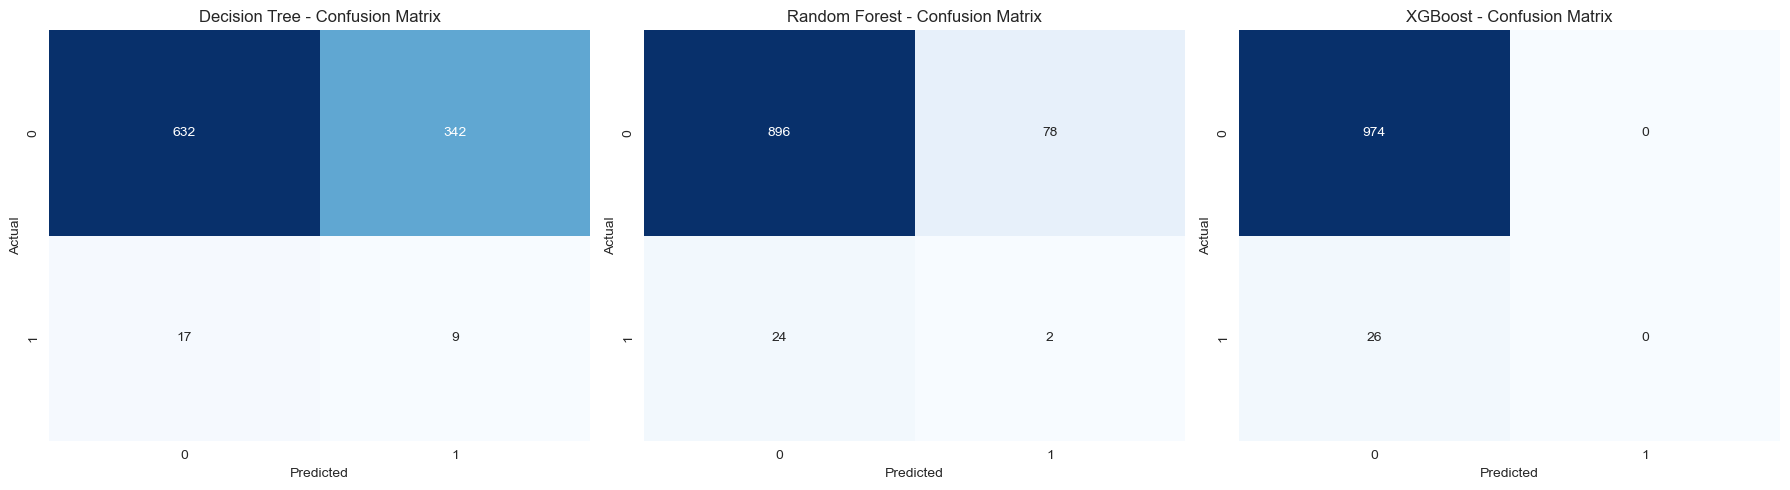

In [33]:
# Create confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for ax, (name, predictions) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [34]:
# Calculate evaluation metrics

results = []

model_predictions = {
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob)
}

for model_name, (predictions, probabilities) in model_predictions.items():
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.641,0.025641,0.346154,0.047745,0.493346
1,Random Forest,0.898,0.025000,0.076923,0.037736,0.546794
2,XGBoost,0.974,0.000000,0.000000,0.000000,0.544898


In [35]:
# Identify the best-performing model based on F1-Score

best_model = results_df.iloc[0]

print("Best Performing Model:", best_model["Model"])
print("F1-Score:", round(best_model["F1-Score"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("ROC-AUC:", round(best_model["ROC-AUC"], 4))

Best Performing Model: Decision Tree
F1-Score: 0.0477
Precision: 0.0256
Recall: 0.3462
ROC-AUC: 0.4933


In [36]:
# Calculate evaluation metrics

results = []

models = {
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest": (rf_pred, rf_prob),
    "XGBoost": (xgb_pred, xgb_prob)
}

for model_name, (predictions, probabilities) in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.641,0.025641,0.346154,0.047745,0.493346
1,Random Forest,0.898,0.025000,0.076923,0.037736,0.546794
2,XGBoost,0.974,0.000000,0.000000,0.000000,0.544898


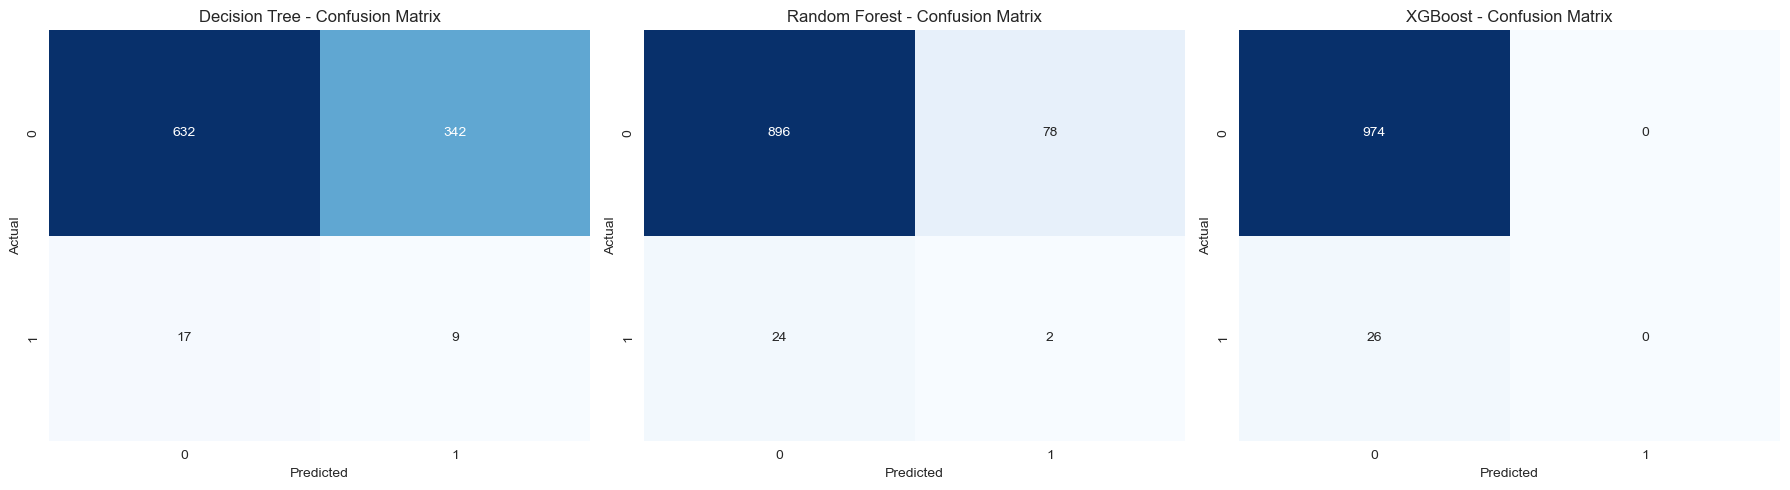

In [37]:
from sklearn.metrics import confusion_matrix

# Confusion matrices
models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, predictions) in zip(axes, models.items()):

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{model_name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import classification_report

print("=" * 60)
print("DECISION TREE")
print("=" * 60)
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Not Fraudulent", "Fraudulent"],
    zero_division=0
))

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Not Fraudulent", "Fraudulent"],
    zero_division=0
))

print("=" * 60)
print("XGBOOST")
print("=" * 60)
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Not Fraudulent", "Fraudulent"],
    zero_division=0
))

DECISION TREE
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.65      0.78       974
    Fraudulent       0.03      0.35      0.05        26

      accuracy                           0.64      1000
     macro avg       0.50      0.50      0.41      1000
  weighted avg       0.95      0.64      0.76      1000

RANDOM FOREST
                precision    recall  f1-score   support

Not Fraudulent       0.97      0.92      0.95       974
    Fraudulent       0.03      0.08      0.04        26

      accuracy                           0.90      1000
     macro avg       0.50      0.50      0.49      1000
  weighted avg       0.95      0.90      0.92      1000

XGBOOST
                precision    recall  f1-score   support

Not Fraudulent       0.97      1.00      0.99       974
    Fraudulent       0.00      0.00      0.00        26

      accuracy                           0.97      1000
     macro avg       0.49      0.50      0.49      1000
  we

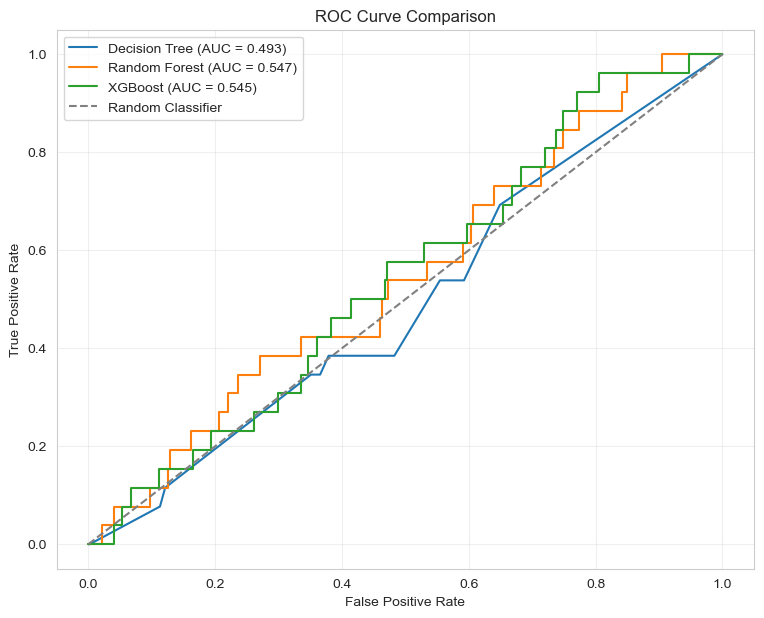

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(
    dt_fpr, dt_tpr,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_prob):.3f})"
)

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    xgb_fpr, xgb_tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

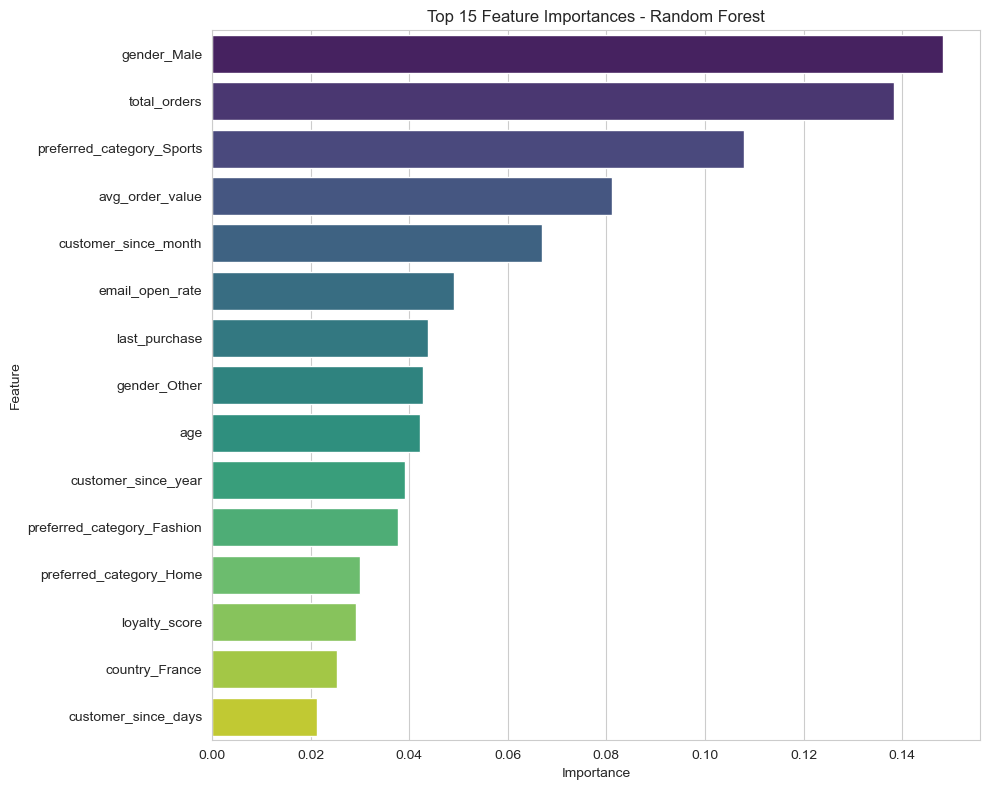

,Feature,Importance
10,gender_Male,0.148358
2,total_orders,0.138256
24,preferred_category_Sports,0.107949
1,avg_order_value,0.081217
8,customer_since_month,0.067030
4,email_open_rate,0.049095
3,last_purchase,0.043873
11,gender_Other,0.042769
0,age,0.042259
7,customer_since_year,0.039043


In [40]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

rf_importance.head(15)

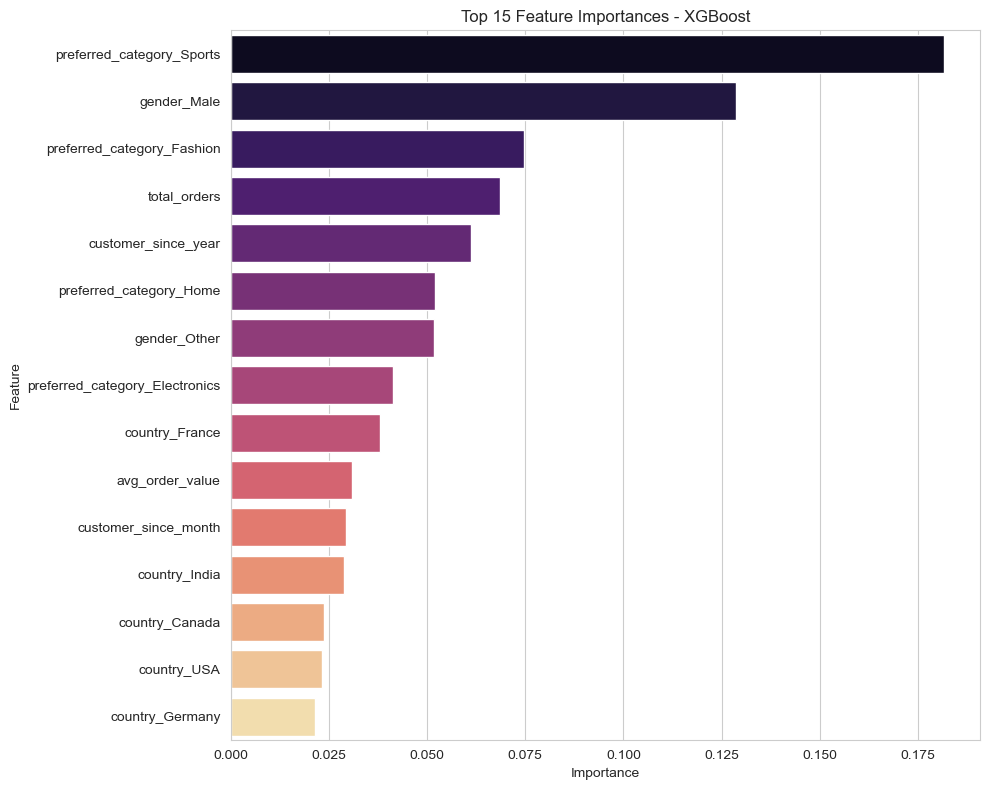

,Feature,Importance
24,preferred_category_Sports,0.181711
10,gender_Male,0.128555
22,preferred_category_Fashion,0.074611
2,total_orders,0.068542
7,customer_since_year,0.061158
23,preferred_category_Home,0.051944
11,gender_Other,0.051797
21,preferred_category_Electronics,0.041312
15,country_France,0.038078
1,avg_order_value,0.030931


In [41]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

xgb_importance.head(15)

In [42]:
# Final Model Comparison

final_results = results_df.copy()

# Round values for better presentation
final_results[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]] = final_results[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]].round(4)

display(final_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.641,0.0256,0.3462,0.0477,0.4933
1,Random Forest,0.898,0.0250,0.0769,0.0377,0.5468
2,XGBoost,0.974,0.0000,0.0000,0.0000,0.5449


In [43]:
# Select best model based on F1-Score

best_model_row = final_results.loc[
    final_results["F1-Score"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print("Accuracy :", best_model_row["Accuracy"])
print("Precision:", best_model_row["Precision"])
print("Recall   :", best_model_row["Recall"])
print("F1-Score :", best_model_row["F1-Score"])
print("ROC-AUC  :", best_model_row["ROC-AUC"])

Best Model: Decision Tree
Accuracy : 0.641
Precision: 0.0256
Recall   : 0.3462
F1-Score : 0.0477
ROC-AUC  : 0.4933


## 18. Final Conclusion

In this project, a complete Machine Learning pipeline was developed for **Customer Fraud Detection – Binary Classification**.

The dataset contained **5,000 customer records and 13 original features**. During EDA, it was found that the target variable was highly imbalanced: **4,871 customers (97.42%) were non-fraudulent, while only 129 customers (2.58%) were fraudulent**.

The data was prepared by handling missing values, checking duplicate records, extracting useful information from the `customer_since` date, removing the customer identifier, and applying one-hot encoding to categorical variables. The dataset was then divided into training and testing sets using stratified sampling.

Because of the strong class imbalance, **SMOTE** was applied only to the training data. This balanced the training classes from 3,897 non-fraudulent and 103 fraudulent observations to 3,897 observations in each class.

Three classification algorithms were trained:

* Decision Tree
* Random Forest
* XGBoost

The models were evaluated using **Accuracy, Precision, Recall, F1-Score, and ROC-AUC**. Accuracy alone was not considered sufficient because fraud detection is a highly imbalanced classification problem.

Based on the obtained results, the **Decision Tree performed comparatively better at identifying fraudulent customers**, achieving a recall of approximately **34.62%** and an F1-score of approximately **4.77%**. Random Forest achieved a recall of approximately **7.69%**, while XGBoost achieved **0% recall**, meaning it did not identify any fraudulent customers in the test set.

Although XGBoost achieved the highest accuracy of approximately **97.4%**, this high accuracy is misleading because the dataset contains a very large majority of non-fraudulent customers. Therefore, the Decision Tree is considered the more useful model among the three for the current fraud-detection objective because it detected a larger proportion of actual fraudulent cases.

Overall, the project demonstrates the importance of **EDA, preprocessing, categorical encoding, feature scaling, class balancing with SMOTE, and appropriate evaluation metrics** when working with highly imbalanced fraud-detection datasets.


In [44]:
# Project Summary

print("=" * 60)
print("CUSTOMER FRAUD DETECTION - PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset Size: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Fraudulent Cases: {df['is_fraudulent'].sum()}")
print(f"Non-Fraudulent Cases: {(df['is_fraudulent'] == 0).sum()}")

print("\nModels Evaluated:")
print("1. Decision Tree")
print("2. Random Forest")
print("3. XGBoost")

print("\nBest Model based on F1-Score:")
print(best_model_row["Model"])

CUSTOMER FRAUD DETECTION - PROJECT SUMMARY
Dataset Size: 5000 rows × 13 columns
Fraudulent Cases: 129
Non-Fraudulent Cases: 4871

Models Evaluated:
1. Decision Tree
2. Random Forest
3. XGBoost

Best Model based on F1-Score:
Decision Tree
